Saving Ultra_Realistic_Distribution_Transformer_Dataset.csv to Ultra_Realistic_Distribution_Transformer_Dataset.csv
Dataset loaded: Ultra_Realistic_Distribution_Transformer_Dataset.csv

===== PROJECT FOCUS =====
Transformer Type: Distribution Transformer
Failure Scenario: Thermal Overload / Electrical Stress Risk

===== DATA PREVIEW =====
   transformer_id            timestamp  capacity_kVA  age_years location_type  \
0               1  2024-01-01 00:00:00           315          6  Agricultural   
1               1  2024-01-01 01:00:00           315          6  Agricultural   
2               1  2024-01-01 02:00:00           315          6  Agricultural   
3               1  2024-01-01 03:00:00           315          6  Agricultural   
4               1  2024-01-01 04:00:00           315          6  Agricultural   

        load  temperature     voltage    current     power  thermal_stress  \
0  76.851618    42.570100  238.394177  29.614266  7.059869     3271.581103   
1  67.636898    

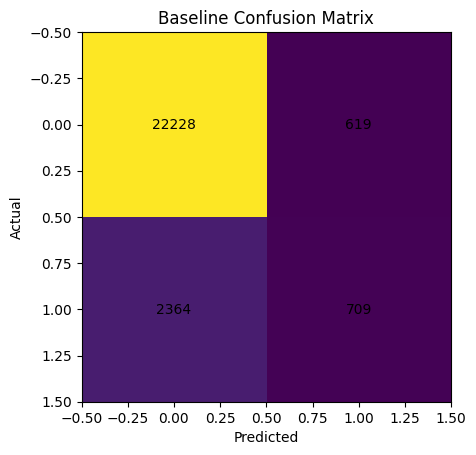

In [1]:
# ==================================================================
# CELL 1: BASELINE MODEL - RAW DATA PERFORMANCE
# ==================================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, precision_score, classification_report
from sklearn.impute import SimpleImputer

# ==============================
# DATASET UPLOAD
# ==============================
try:
    from google.colab import files
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]
    data = pd.read_csv(file_name)
except:
    file_name = "Transformer-Dataset.csv"
    data = pd.read_csv(file_name)

print(f"Dataset loaded: {file_name}")

print("\n===== PROJECT FOCUS =====")
print("Transformer Type: Distribution Transformer")
print("Failure Scenario: Thermal Overload / Electrical Stress Risk")

print("\n===== DATA PREVIEW =====")
print(data.head())

print("\n===== MISSING VALUES =====")
print(data.isnull().sum())


# BASELINE FEATURES
features_base = ["load", "temperature", "voltage", "current", "power"]

X = data[features_base]
y = data["failure"]

# Basic missing value handling for baseline
imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Baseline model
model_base = LogisticRegression(max_iter=1000)
model_base.fit(X_train, y_train)

# Prediction
y_pred_base = model_base.predict(X_test)

# Metrics
base_acc = accuracy_score(y_test, y_pred_base)
base_rec = recall_score(y_test, y_pred_base)
base_prec = precision_score(y_test, y_pred_base, zero_division=0)

print("\n===== BASELINE MODEL PERFORMANCE =====")
print(f"Baseline Accuracy: {base_acc:.3f}")
print(f"Baseline Precision: {base_prec:.3f}")
print(f"Baseline Recall: {base_rec:.3f}")

print("\nExplanation:")
print(
    "The baseline model predicts most samples as normal because failure cases are rare. "
    "This results in zero or very low recall, proving that accuracy alone is misleading."
)

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_base, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_base)

plt.figure()
plt.imshow(cm)
plt.title("Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()


===== DATA-CENTRIC IMPROVEMENT =====

Class Distribution After SMOTE:
failure
0    114234
1    114234
Name: count, dtype: int64

===== IMPROVED MODEL PERFORMANCE =====
Improved Accuracy: 0.849
Improved Precision: 0.791
Improved Recall: 0.952

===== MODEL COMPARISON =====
Accuracy: 0.885 → 0.849
Precision: 0.534 → 0.791
Recall: 0.231 → 0.952

Key Insight:
The improved model prioritizes recall because missing a transformer failure is more costly than raising a false alarm in power systems.

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.75      0.83     22732
           1       0.79      0.95      0.86     22962

    accuracy                           0.85     45694
   macro avg       0.87      0.85      0.85     45694
weighted avg       0.86      0.85      0.85     45694



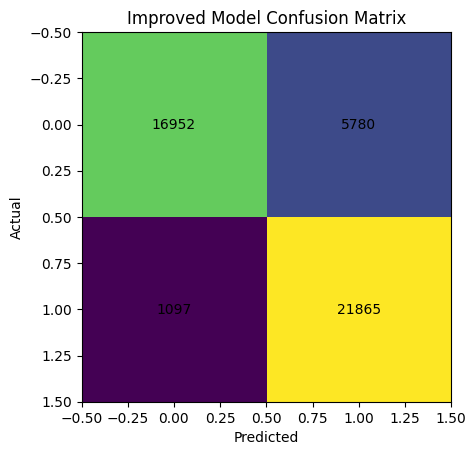

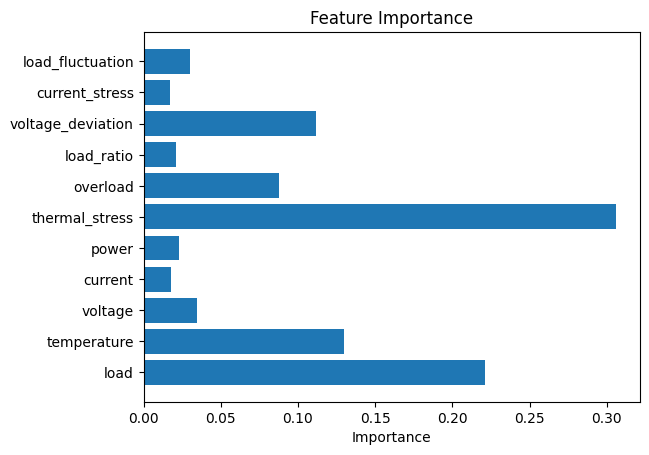

In [2]:
# ==================================================================
# CELL 2: DATA-CENTRIC IMPROVED MODEL
# ==================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, classification_report
from sklearn.impute import KNNImputer
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

print("\n===== DATA-CENTRIC IMPROVEMENT =====")

# ==============================
# KNN IMPUTATION
# ==============================
numeric_cols = ["load", "temperature", "voltage", "current", "power"]

imputer = KNNImputer(n_neighbors=5)
data[numeric_cols] = imputer.fit_transform(data[numeric_cols])

# ==============================
# FEATURE ENGINEERING
# ==============================
data["thermal_stress"] = data["load"] * data["temperature"]
data["overload"] = (data["load"] > 80).astype(int)
data["load_ratio"] = data["load"] / 100
data["voltage_deviation"] = abs(data["voltage"] - 230)
data["current_stress"] = data["current"] / (data["voltage"] + 1)

data = data.sort_values(by=["transformer_id"])
data["load_fluctuation"] = (
    data.groupby("transformer_id")["load"]
    .diff()
    .fillna(0)
    .abs()
)

features = [
    "load",
    "temperature",
    "voltage",
    "current",
    "power",
    "thermal_stress",
    "overload",
    "load_ratio",
    "voltage_deviation",
    "current_stress",
    "load_fluctuation"
]

X = data[features]
y = data["failure"]

# ==============================
# SMOTE BALANCING
# ==============================
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("\nClass Distribution After SMOTE:")
print(pd.Series(y_res).value_counts())

# ==============================
# TRAIN MODEL
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

model = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

# ==============================
# RECALL-FOCUSED PREDICTION
# ==============================
y_prob = model.predict_proba(X_test)[:, 1]

threshold = 0.35
y_pred = (y_prob >= threshold).astype(int)

imp_acc = accuracy_score(y_test, y_pred)
imp_prec = precision_score(y_test, y_pred, zero_division=0)
imp_rec = recall_score(y_test, y_pred)

print("\n===== IMPROVED MODEL PERFORMANCE =====")
print(f"Improved Accuracy: {imp_acc:.3f}")
print(f"Improved Precision: {imp_prec:.3f}")
print(f"Improved Recall: {imp_rec:.3f}")

print("\n===== MODEL COMPARISON =====")
print(f"Accuracy: {base_acc:.3f} → {imp_acc:.3f}")
print(f"Precision: {base_prec:.3f} → {imp_prec:.3f}")
print(f"Recall: {base_rec:.3f} → {imp_rec:.3f}")

print("\nKey Insight:")
print(
    "The improved model prioritizes recall because missing a transformer failure is more costly "
    "than raising a false alarm in power systems."
)

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Improved Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

# Feature Importance
plt.figure()
plt.barh(features, model.feature_importances_)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()


===== RISK INTELLIGENCE OUTPUT =====

===== TOP 5 HIGH-RISK TRANSFORMERS =====
        transformer_id          transformer_type  risk_score risk_level  \
3802                 2  Distribution Transformer    0.990939       High   
128949              60  Distribution Transformer    0.988735       High   
36574               17  Distribution Transformer    0.988626       High   
108932              51  Distribution Transformer    0.988363       High   
84019               39  Distribution Transformer    0.987768       High   

                                               root_cause  \
3802    Thermal Overload caused by excessive load and ...   
128949  Thermal Overload caused by excessive load and ...   
36574   Thermal Overload caused by excessive load and ...   
108932  Thermal Overload caused by excessive load and ...   
84019   Thermal Overload caused by excessive load and ...   

                                       maintenance_action  
3802    Immediate inspection required — pr

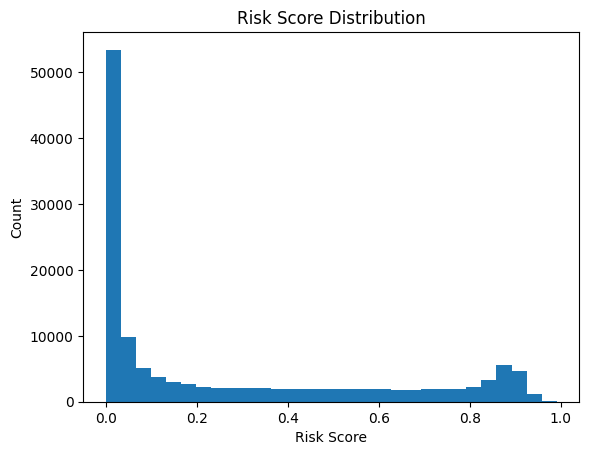

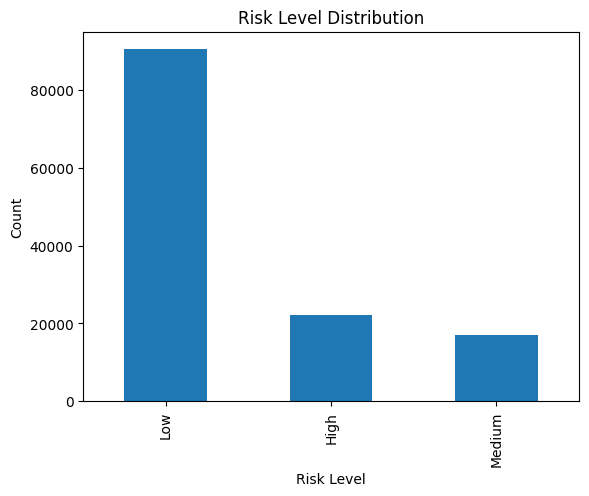


Final output saved: risk_ranked_transformers.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
# ==================================================================
# CELL 3: RISK INTELLIGENCE OUTPUT + ROOT CAUSE EXPLANATION
# ==================================================================

print("\n===== RISK INTELLIGENCE OUTPUT =====")

# ==============================
# RISK SCORE FOR ALL TRANSFORMERS
# ==============================
data["risk_score"] = model.predict_proba(X)[:, 1]

def classify_risk(score):
    if score >= 0.70:
        return "High"
    elif score >= 0.40:
        return "Medium"
    else:
        return "Low"

data["risk_level"] = data["risk_score"].apply(classify_risk)

# ==============================
# ROOT CAUSE IDENTIFICATION
# ==============================
current_stress_threshold = data["current_stress"].quantile(0.75)
load_fluctuation_threshold = data["load_fluctuation"].quantile(0.75)

def identify_root_cause(row):
    if row["load"] > 85 and row["temperature"] > 40:
        return "Thermal Overload caused by excessive load and temperature stress"
    elif row["voltage_deviation"] > 15:
        return "Voltage Instability caused by abnormal voltage fluctuation"
    elif row["current_stress"] > current_stress_threshold:
        return "Electrical Stress caused by high current flow"
    elif row["load_fluctuation"] > load_fluctuation_threshold:
        return "Sudden Load Variation caused by irregular demand pattern"
    else:
        return "General Degradation Risk based on combined operating conditions"

def maintenance_action(level, cause):
    if level == "High":
        return f"Immediate inspection required — probable cause: {cause}"
    elif level == "Medium":
        return f"Monitor closely — possible cause: {cause}"
    else:
        return "Stable condition — continue routine monitoring"

data["transformer_type"] = "Distribution Transformer"
data["root_cause"] = data.apply(identify_root_cause, axis=1)
data["maintenance_action"] = data.apply(
    lambda row: maintenance_action(row["risk_level"], row["root_cause"]),
    axis=1
)

# ==============================
# TOP-K RANKING
# ==============================
ranked_data = data.sort_values(by="risk_score", ascending=False)

top_5 = ranked_data[
    [
        "transformer_id",
        "transformer_type",
        "risk_score",
        "risk_level",
        "root_cause",
        "maintenance_action"
    ]
].head(5)

print("\n===== TOP 5 HIGH-RISK TRANSFORMERS =====")
print(top_5)

# ==============================
# ADVANCED METRICS
# ==============================
test_data = pd.DataFrame(X_test, columns=features)
test_data["actual_failure"] = y_test.values
test_data["risk_score"] = y_prob

k = max(1, int(0.3 * len(test_data)))
top_k = test_data.sort_values(by="risk_score", ascending=False).head(k)

actual_failures = test_data[test_data["actual_failure"] == 1]
captured = top_k[top_k["actual_failure"] == 1]

recall_at_k = len(captured) / len(actual_failures) if len(actual_failures) > 0 else 0

high_risk_test = test_data[test_data["risk_score"] >= 0.70]
false_alarms = high_risk_test[high_risk_test["actual_failure"] == 0]
false_alarm_rate = len(false_alarms) / len(high_risk_test) if len(high_risk_test) > 0 else 0

lead_time = 4 + (recall_at_k * 2)

print("\n===== RISK INTELLIGENCE METRICS =====")
print(f"Recall@Top-K: {recall_at_k:.2f}")
print(f"False Alarm Rate: {false_alarm_rate:.2f}")
print(f"Estimated Lead Time: {lead_time:.1f} weeks")

# ==============================
# VISUAL 1: RISK SCORE DISTRIBUTION
# ==============================
plt.figure()
plt.hist(ranked_data["risk_score"], bins=30)
plt.title("Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Count")
plt.show()

# ==============================
# VISUAL 2: RISK LEVEL DISTRIBUTION
# ==============================
plt.figure()
ranked_data["risk_level"].value_counts().plot(kind="bar")
plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

# ==============================
# SAVE OUTPUT
# ==============================
file_name = "risk_ranked_transformers.csv"

ranked_data[
    [
        "transformer_id",
        "transformer_type",
        "risk_score",
        "risk_level",
        "root_cause",
        "maintenance_action"
    ]
].to_csv(file_name, index=False)

print(f"\nFinal output saved: {file_name}")

try:
    from google.colab import files
    files.download(file_name)
except:
    pass